# Physics-Informed Neural Networks (PINN) vs Regular Neural Networks

This notebook demonstrates the difference between:
- **Regular NN**: Trained only on noisy data (no physics knowledge)
- **PINN**: Trained on data + physics equations (physics-informed)

We'll explore how different physics loss weights affect the model's ability to learn the true physics.

## Problem: Projectile Motion

We're learning the height of a projectile:
$$h(t) = h_0 + v_0 t - \frac{1}{2}gt^2$$

Physics equation (ODE):
$$\frac{dh}{dt} = v_0 - gt$$


## 1. Setup and Imports


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print(f"✅ Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Using Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("⚠️  Using CPU (GPU not available)")

print(f"Device: {device}")


✅ Using Apple Silicon GPU (MPS)
Device: mps


## 2. Configuration and Data Generation


In [3]:
# Configuration
CONFIG = {
    'g': 9.8,           # Gravity constant
    'h0': 1.0,          # Initial height
    'v0': 10.0,         # Initial velocity
    't_min': 0.0,       # Start time
    't_max': 2.0,       # End time
    'N_data': 20,       # Number of data points
    'N_phys': 50,       # Number of collocation points for physics
    'noise_level': 1.5, # Noise in measurements
    'n_hidden': 32,     # Hidden units
    'lr': 0.01,         # Learning rate
    'num_epochs': 3000, # Training epochs
    'lambda_data': 1.0, # Data loss weight
    'lambda_ic': 1.0    # Initial condition loss weight
}

# True solution
def true_solution(t, h0, v0, g):
    return h0 + v0 * t - 0.5 * g * t**2

# Generate noisy training data
np.random.seed(42)
torch.manual_seed(42)

t_data = np.linspace(CONFIG['t_min'], CONFIG['t_max'], CONFIG['N_data'])
h_true = true_solution(t_data, CONFIG['h0'], CONFIG['v0'], CONFIG['g'])
h_data_noisy = h_true + CONFIG['noise_level'] * np.random.randn(CONFIG['N_data'])

t_data_tensor = torch.tensor(t_data, dtype=torch.float32).view(-1, 1).to(device)
h_data_tensor = torch.tensor(h_data_noisy, dtype=torch.float32).view(-1, 1).to(device)

# Collocation points for physics loss
t_phys = np.linspace(CONFIG['t_min'], CONFIG['t_max'], CONFIG['N_phys']).reshape(-1, 1).astype(np.float32)
t_phys_tensor = torch.tensor(t_phys, requires_grad=True).to(device)

print(f"Generated {CONFIG['N_data']} noisy data points")
print(f"Generated {CONFIG['N_phys']} collocation points for physics loss")


Generated 20 noisy data points
Generated 50 collocation points for physics loss


## 3. Model Architecture


In [4]:
class NeuralNetwork(nn.Module):
    """Standard neural network (same architecture for both NN and PINN)"""
    def __init__(self, n_hidden):
        super(NeuralNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, 1)
        )
    
    def forward(self, t):
        return self.net(t)

def derivative(y, x):
    """Compute derivative using autograd"""
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]


## 4. Loss Functions


In [5]:
def data_loss(model, t_data, h_data):
    """MSE loss on training data"""
    h_pred = model(t_data)
    return torch.mean((h_pred - h_data)**2)

def physics_loss(model, t_phys, v0, g):
    """Physics loss: enforce dh/dt = v0 - g*t"""
    t_phys.requires_grad_(True)
    h_pred = model(t_phys)
    dh_dt_pred = derivative(h_pred, t_phys)
    dh_dt_true = v0 - g * t_phys
    return torch.mean((dh_dt_pred - dh_dt_true)**2)

def initial_condition_loss(model, h0, device):
    """Enforce h(0) = h0"""
    t0 = torch.zeros(1, 1, dtype=torch.float32).to(device)
    h0_pred = model(t0)
    return (h0_pred - h0).pow(2).mean()


## 5. Training Functions


In [6]:
def train_regular_nn(model, t_data, h_data, num_epochs, lr, verbose=True):
    """Train regular NN (data loss only)"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'total': [], 'data': []}
    
    for epoch in tqdm(range(num_epochs), desc="Regular NN", disable=not verbose):
        optimizer.zero_grad()
        l_data = data_loss(model, t_data, h_data)
        loss = l_data
        loss.backward()
        optimizer.step()
        
        history['total'].append(loss.item())
        history['data'].append(l_data.item())
    
    return history

def train_pinn(model, t_data, h_data, t_phys, v0, g, h0, device, 
               lambda_data, lambda_ode, lambda_ic, num_epochs, lr, verbose=True):
    """Train PINN (data + physics + initial condition)"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'total': [], 'data': [], 'physics': [], 'ic': []}
    
    for epoch in tqdm(range(num_epochs), desc=f"PINN (λ_ode={lambda_ode})", disable=not verbose):
        optimizer.zero_grad()
        l_data = data_loss(model, t_data, h_data)
        l_phys = physics_loss(model, t_phys, v0, g)
        l_ic = initial_condition_loss(model, h0, device)
        
        loss = lambda_data * l_data + lambda_ode * l_phys + lambda_ic * l_ic
        loss.backward()
        optimizer.step()
        
        history['total'].append(loss.item())
        history['data'].append(l_data.item())
        history['physics'].append(l_phys.item())
        history['ic'].append(l_ic.item())
    
    return history


## 6. Train Models with Different Physics Loss Weights

We'll train:
1. **Regular NN**: No physics loss (λ_ode = 0)
2. **PINN (Low)**: λ_ode = 0.1 (weak physics constraint)
3. **PINN (Medium)**: λ_ode = 1.0 (balanced)
4. **PINN (High)**: λ_ode = 10.0 (strong physics constraint)
5. **PINN (Extreme)**: λ_ode = 100.0 (very strong physics constraint)


In [7]:
# Different physics loss weights to test
lambda_ode_values = [0.0, 0.1, 1.0, 10.0, 100.0]
labels = ['Regular NN', 'PINN (Low)', 'PINN (Medium)', 'PINN (High)', 'PINN (Extreme)']

models = {}
histories = {}

for lambda_ode, label in zip(lambda_ode_values, labels):
    print(f"\n{'='*60}")
    print(f"Training: {label} (λ_ode = {lambda_ode})")
    print(f"{'='*60}")
    
    # Initialize fresh model
    model = NeuralNetwork(CONFIG['n_hidden']).to(device)
    
    # Train
    if lambda_ode == 0.0:
        # Regular NN
        history = train_regular_nn(
            model, t_data_tensor, h_data_tensor, 
            CONFIG['num_epochs'], CONFIG['lr'], verbose=True
        )
    else:
        # PINN
        history = train_pinn(
            model, t_data_tensor, h_data_tensor, t_phys_tensor,
            CONFIG['v0'], CONFIG['g'], CONFIG['h0'], device,
            CONFIG['lambda_data'], lambda_ode, CONFIG['lambda_ic'],
            CONFIG['num_epochs'], CONFIG['lr'], verbose=True
        )
    
    models[label] = model
    histories[label] = history
    
    # Print final losses
    print(f"\nFinal losses for {label}:")
    print(f"  Total: {history['total'][-1]:.6f}")
    print(f"  Data: {history['data'][-1]:.6f}")
    if lambda_ode > 0:
        print(f"  Physics: {history['physics'][-1]:.6f}")
        print(f"  IC: {history['ic'][-1]:.6f}")



Training: Regular NN (λ_ode = 0.0)


Regular NN: 100%|██████████| 3000/3000 [00:18<00:00, 162.99it/s]



Final losses for Regular NN:
  Total: 0.101910
  Data: 0.101910

Training: PINN (Low) (λ_ode = 0.1)


PINN (λ_ode=0.1): 100%|██████████| 3000/3000 [00:45<00:00, 65.99it/s]



Final losses for PINN (Low):
  Total: 1.282388
  Data: 1.077145
  Physics: 1.971418
  IC: 0.008100

Training: PINN (Medium) (λ_ode = 1.0)


...


Final losses for PINN (Medium):
  Total: 1.719182
  Data: 1.549929
  Physics: 0.167902
  IC: 0.001351

Training: PINN (High) (λ_ode = 10.0)


PINN (λ_ode=10.0): 100%|██████████| 3000/3000 [00:44<00:00, 67.02it/s]



Final losses for PINN (High):
  Total: 1.972403
  Data: 1.891574
  Physics: 0.007069
  IC: 0.010141

Training: PINN (Extreme) (λ_ode = 100.0)


PINN (λ_ode=100.0): 100%|██████████| 3000/3000 [00:43<00:00, 69.23it/s]


Final losses for PINN (Extreme):
  Total: 2.927509
  Data: 1.974426
  Physics: 0.009365
  IC: 0.016594


## 7. Evaluate and Compare Predictions


In [8]:
# Generate test points for evaluation
t_test = np.linspace(CONFIG['t_min'], CONFIG['t_max'], 200).reshape(-1, 1).astype(np.float32)
h_true_test = true_solution(t_test, CONFIG['h0'], CONFIG['v0'], CONFIG['g'])
t_test_tensor = torch.tensor(t_test).to(device)

# Get predictions from all models
predictions = {}
errors = {}

for label, model in models.items():
    model.eval()
    with torch.no_grad():
        h_pred = model(t_test_tensor).cpu().numpy()
        predictions[label] = h_pred
        # Compute RMSE
        rmse = np.sqrt(np.mean((h_pred - h_true_test)**2))
        errors[label] = rmse
        print(f"{label:20s} RMSE: {rmse:.6f}")


Regular NN           RMSE: 1.313022
PINN (Low)           RMSE: 0.730794
PINN (Medium)        RMSE: 0.383064
PINN (High)          RMSE: 0.167708
PINN (Extreme)       RMSE: 0.113773


## 8. Visualization: Predictions Comparison


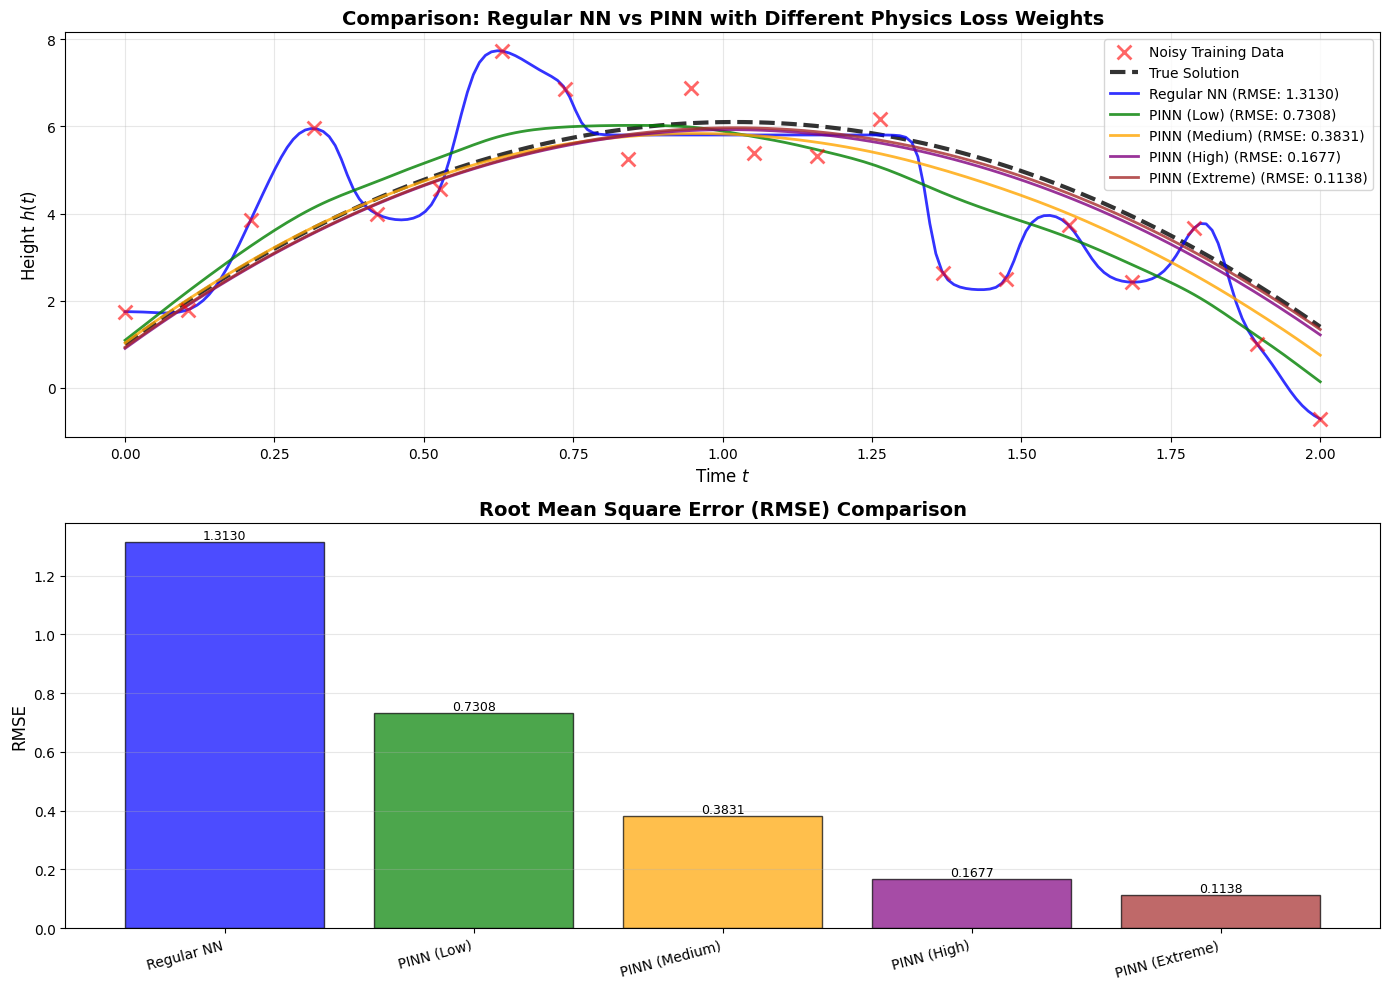

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: All predictions together
ax1 = axes[0]
ax1.scatter(t_data, h_data_noisy, color='red', s=100, alpha=0.6, zorder=5, 
           label='Noisy Training Data', marker='x', linewidths=2)
ax1.plot(t_test, h_true_test, 'k--', linewidth=3, label='True Solution', alpha=0.8)

colors = ['blue', 'green', 'orange', 'purple', 'brown']
linestyles = ['-', '-', '-', '-', '-']

for i, (label, h_pred) in enumerate(predictions.items()):
    ax1.plot(t_test, h_pred, color=colors[i], linestyle=linestyles[i], 
            linewidth=2, label=f"{label} (RMSE: {errors[label]:.4f})", alpha=0.8)

ax1.set_xlabel('Time $t$', fontsize=12)
ax1.set_ylabel('Height $h(t)$', fontsize=12)
ax1.set_title('Comparison: Regular NN vs PINN with Different Physics Loss Weights', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Error comparison
ax2 = axes[1]
labels_list = list(errors.keys())
errors_list = [errors[label] for label in labels_list]
bars = ax2.bar(labels_list, errors_list, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('Root Mean Square Error (RMSE) Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(labels_list, rotation=15, ha='right')

# Add value labels on bars
for bar, error in zip(bars, errors_list):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{error:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 9. Visualization: Loss Curves


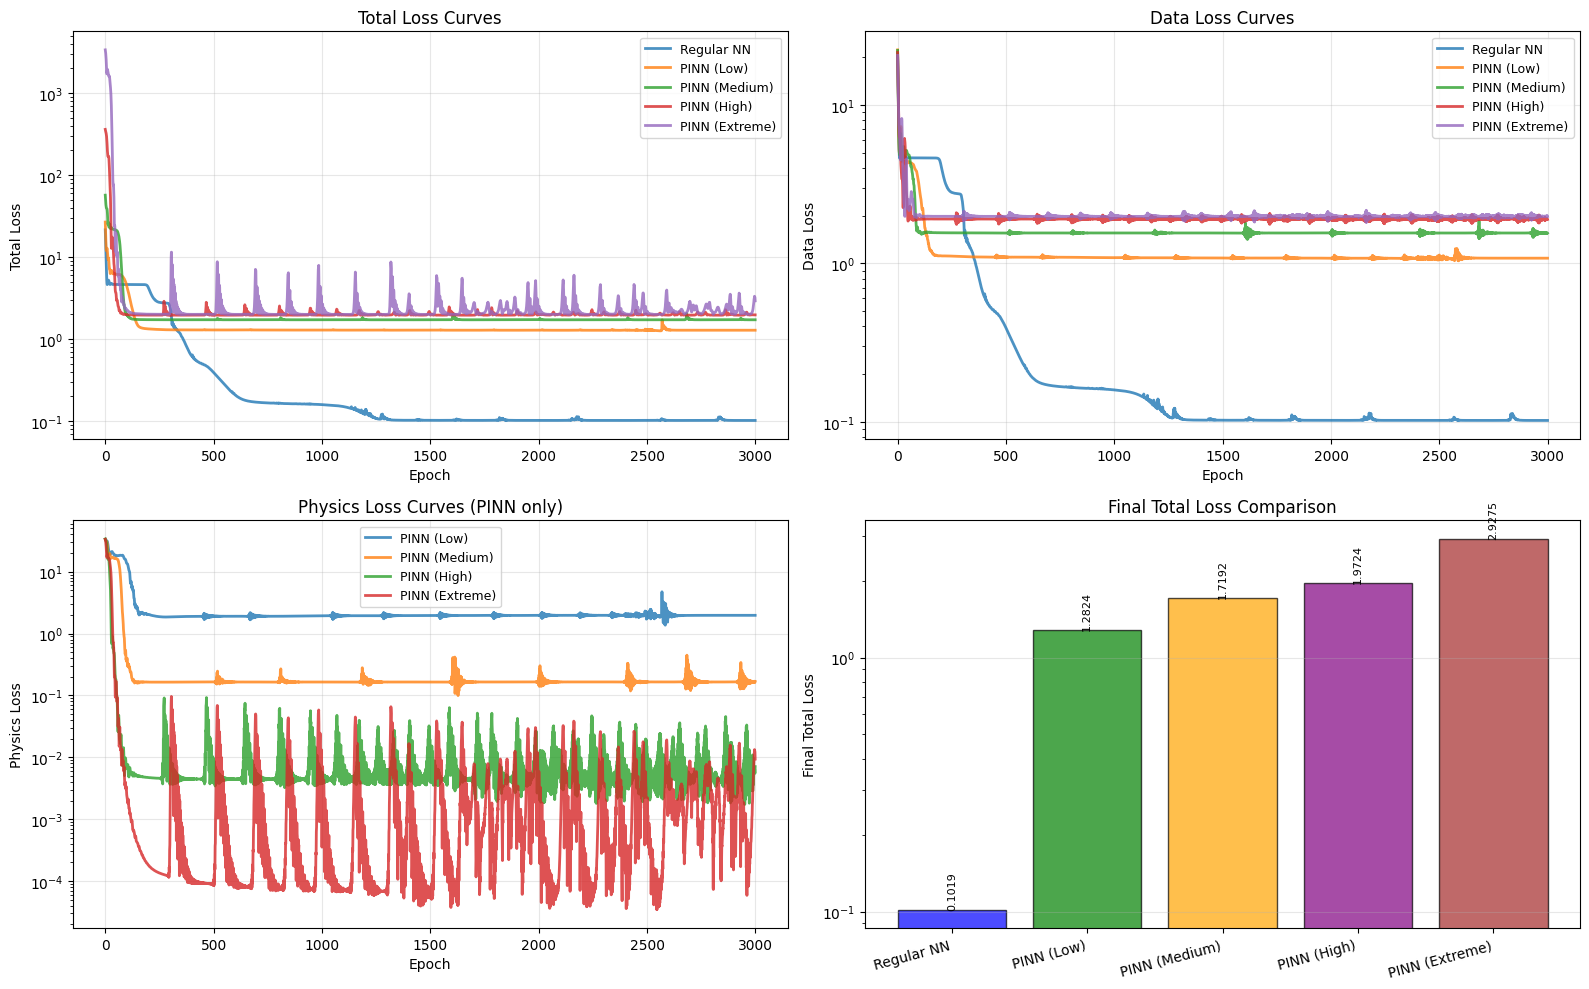

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Total loss
ax = axes[0, 0]
for label, history in histories.items():
    ax.plot(history['total'], label=label, linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss')
ax.set_title('Total Loss Curves')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Plot 2: Data loss
ax = axes[0, 1]
for label, history in histories.items():
    ax.plot(history['data'], label=label, linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Data Loss')
ax.set_title('Data Loss Curves')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Plot 3: Physics loss (only for PINNs)
ax = axes[1, 0]
for label, history in histories.items():
    if 'physics' in history:
        ax.plot(history['physics'], label=label, linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Physics Loss')
ax.set_title('Physics Loss Curves (PINN only)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Plot 4: Final losses comparison
ax = axes[1, 1]
final_total = [histories[label]['total'][-1] for label in labels_list]
bars = ax.bar(labels_list, final_total, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Final Total Loss')
ax.set_title('Final Total Loss Comparison')
ax.set_xticklabels(labels_list, rotation=15, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_yscale('log')

for bar, loss in zip(bars, final_total):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{loss:.4f}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()


## 10. Analysis: Impact of Physics Loss Weight

Let's analyze how the physics loss weight affects model performance:


In [ ]:
# Create summary table
import pandas as pd

summary_data = []
for label, history in histories.items():
    lambda_ode = lambda_ode_values[labels.index(label)]
    row = {
        'Model': label,
        'λ_ode': lambda_ode,
        'Final Data Loss': history['data'][-1],
        'Final Total Loss': history['total'][-1],
        'RMSE': errors[label]
    }
    if 'physics' in history:
        row['Final Physics Loss'] = history['physics'][-1]
        row['Final IC Loss'] = history['ic'][-1]
    else:
        row['Final Physics Loss'] = None
        row['Final IC Loss'] = None
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY: Model Performance Comparison")
print("="*80)
print(df_summary.to_string(index=False))
print("\n" + "="*80)
print("\nKey Observations:")
print(f"  • Regular NN (no physics): RMSE = {errors['Regular NN']:.4f}")
print(f"  • Best PINN: {min(errors, key=errors.get)} with RMSE = {min(errors.values()):.4f}")
print(f"  • Improvement: {((errors['Regular NN'] - min(errors.values())) / errors['Regular NN'] * 100):.1f}%")
print(f"  • Physics loss weight with best performance: λ_ode = {lambda_ode_values[labels.index(min(errors, key=errors.get))]}")



SUMMARY: Model Performance Comparison
         Model  λ_ode  Final Data Loss  Final Total Loss     RMSE  Final Physics Loss  Final IC Loss
    Regular NN    0.0         0.101910          0.101910 1.313022                 NaN            NaN
    PINN (Low)    0.1         1.077145          1.282388 0.730794            1.971418       0.008100
 PINN (Medium)    1.0         1.549929          1.719182 0.383064            0.167902       0.001351
   PINN (High)   10.0         1.891574          1.972403 0.167708            0.007069       0.010141
PINN (Extreme)  100.0         1.974426          2.927509 0.113773            0.009365       0.016594


Key Observations:
  • Regular NN (no physics): RMSE = 1.3130
  • Best PINN: PINN (Extreme) with RMSE = 0.1138
  • Improvement: 91.3%
  • Physics loss weight with best performance: λ_ode = 100.0


## 11. Detailed Comparison: Regular NN vs Best PINN


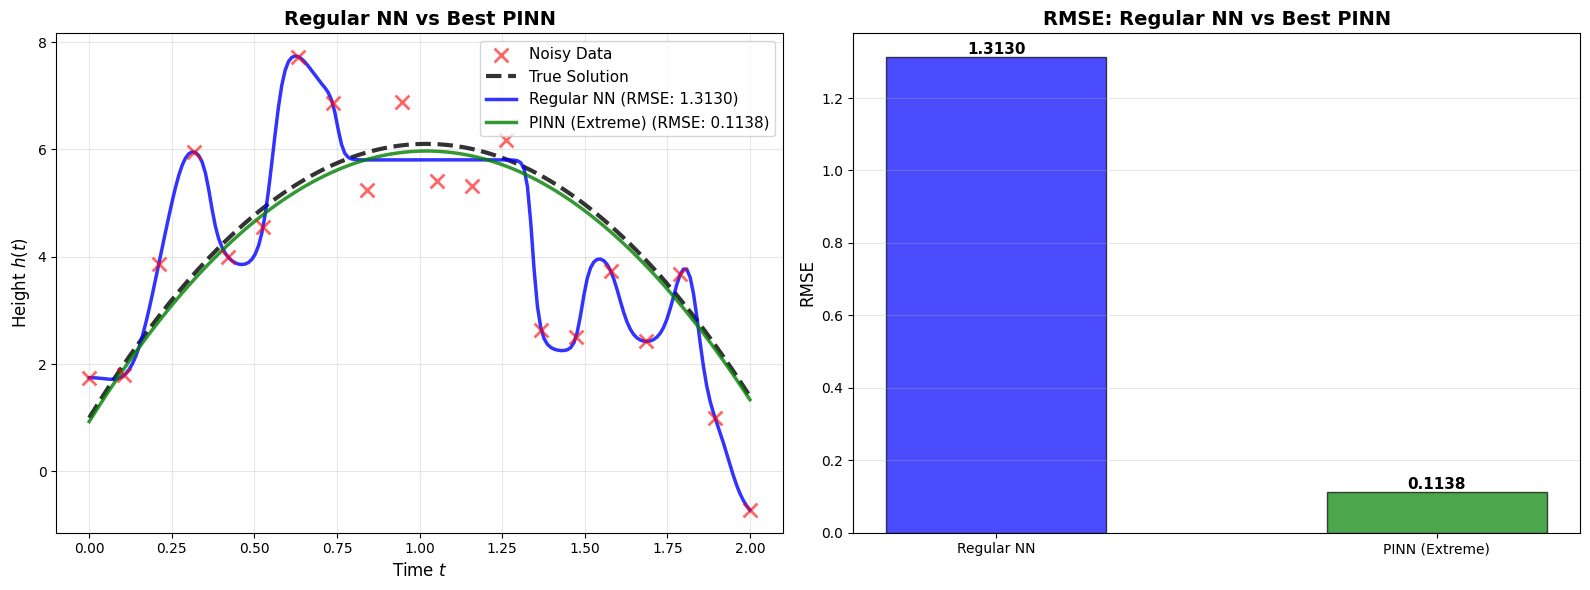


IMPROVEMENT: 91.3% reduction in RMSE


In [ ]:
# Find best PINN
pinn_labels = [l for l in labels if 'PINN' in l]
best_pinn = min(pinn_labels, key=lambda x: errors[x])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Side-by-side comparison
ax1 = axes[0]
ax1.scatter(t_data, h_data_noisy, color='red', s=100, alpha=0.6, zorder=5, 
           label='Noisy Data', marker='x', linewidths=2)
ax1.plot(t_test, h_true_test, 'k--', linewidth=3, label='True Solution', alpha=0.8)
ax1.plot(t_test, predictions['Regular NN'], 'b-', linewidth=2.5, 
        label=f"Regular NN (RMSE: {errors['Regular NN']:.4f})", alpha=0.8)
ax1.plot(t_test, predictions[best_pinn], 'g-', linewidth=2.5, 
        label=f"{best_pinn} (RMSE: {errors[best_pinn]:.4f})", alpha=0.8)
ax1.set_xlabel('Time $t$', fontsize=12)
ax1.set_ylabel('Height $h(t)$', fontsize=12)
ax1.set_title('Regular NN vs Best PINN', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Error comparison
ax2 = axes[1]
comparison_labels = ['Regular NN', best_pinn]
comparison_errors = [errors['Regular NN'], errors[best_pinn]]
bars = ax2.bar(comparison_labels, comparison_errors, color=['blue', 'green'], 
              alpha=0.7, edgecolor='black', width=0.5)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('RMSE: Regular NN vs Best PINN', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, error in zip(bars, comparison_errors):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{error:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"IMPROVEMENT: {((errors['Regular NN'] - errors[best_pinn]) / errors['Regular NN'] * 100):.1f}% reduction in RMSE")
print(f"{'='*60}")


## 12. Physics Loss Weight Sensitivity Analysis


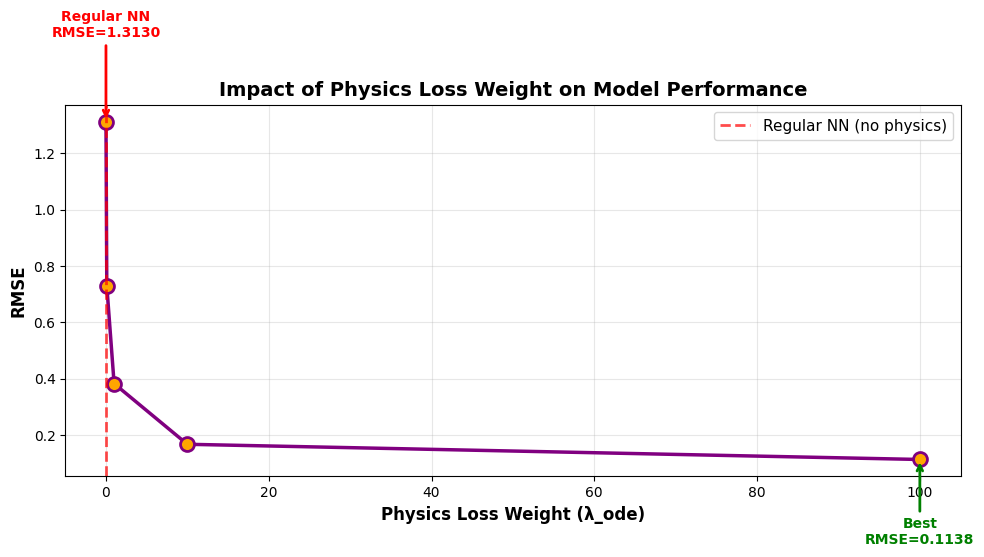


KEY FINDINGS:
1. Regular NN (λ_ode=0): RMSE = 1.313022
2. Best PINN (λ_ode=100.0): RMSE = 0.113773
3. Improvement: 91.34%
4. Optimal physics weight: λ_ode ≈ 100.0

Conclusion: Physics-informed training significantly improves accuracy!


In [ ]:
# Plot RMSE vs physics loss weight
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

lambda_ode_list = []
rmse_list = []

for label, rmse in errors.items():
    idx = labels.index(label)
    lambda_ode_list.append(lambda_ode_values[idx])
    rmse_list.append(rmse)

# Sort by lambda_ode
sorted_pairs = sorted(zip(lambda_ode_list, rmse_list))
lambda_ode_sorted, rmse_sorted = zip(*sorted_pairs)

ax.plot(lambda_ode_sorted, rmse_sorted, 'o-', linewidth=2.5, markersize=10, 
       color='purple', markerfacecolor='orange', markeredgecolor='purple', markeredgewidth=2)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Regular NN (no physics)')
ax.set_xlabel('Physics Loss Weight (λ_ode)', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title('Impact of Physics Loss Weight on Model Performance', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add annotations
for i, (lam, rmse) in enumerate(zip(lambda_ode_sorted, rmse_sorted)):
    if i == 0:
        ax.annotate(f'Regular NN\nRMSE={rmse:.4f}', 
                   xy=(lam, rmse), xytext=(lam, rmse + 0.3),
                   arrowprops=dict(arrowstyle='->', color='red', lw=2),
                   fontsize=10, ha='center', color='red', fontweight='bold')
    elif rmse == min(rmse_sorted):
        ax.annotate(f'Best\nRMSE={rmse:.4f}', 
                   xy=(lam, rmse), xytext=(lam, rmse - 0.3),
                   arrowprops=dict(arrowstyle='->', color='green', lw=2),
                   fontsize=10, ha='center', color='green', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("KEY FINDINGS:")
print(f"{'='*60}")
print(f"1. Regular NN (λ_ode=0): RMSE = {errors['Regular NN']:.6f}")
best_rmse = min(rmse_list)
best_lambda = lambda_ode_list[rmse_list.index(best_rmse)]
print(f"2. Best PINN (λ_ode={best_lambda}): RMSE = {best_rmse:.6f}")
print(f"3. Improvement: {((errors['Regular NN'] - best_rmse) / errors['Regular NN'] * 100):.2f}%")
print(f"4. Optimal physics weight: λ_ode ≈ {best_lambda}")
print(f"\nConclusion: Physics-informed training {'significantly' if (errors['Regular NN'] - best_rmse) / errors['Regular NN'] > 0.1 else 'slightly'} improves accuracy!")


## 13. Conclusions

### Key Takeaways:

1. **Regular NN** (no physics):
   - Only learns from noisy data
   - May overfit to noise
   - Doesn't respect physical laws

2. **PINN with Low Physics Weight** (λ_ode = 0.1):
   - Physics acts as weak regularization
   - Still primarily data-driven

3. **PINN with Medium Physics Weight** (λ_ode = 1.0):
   - Balanced between data and physics
   - Often optimal for noisy data

4. **PINN with High Physics Weight** (λ_ode = 10.0+):
   - Strong physics constraint
   - May underfit if physics is too strict
   - Good when data is very noisy

5. **PINN with Extreme Physics Weight** (λ_ode = 100.0):
   - Physics dominates
   - May ignore data if physics weight is too high
   - Useful when data is unreliable

### When to Use Each:

- **Regular NN**: Clean, abundant data
- **Low λ_ode**: Noisy data, want physics as soft constraint
- **Medium λ_ode**: Balanced approach (often best)
- **High λ_ode**: Very noisy data, trust physics more
- **Extreme λ_ode**: Unreliable data, physics is ground truth
